# 🖼️ EDA - Image Data: Street View House Numbers (SVHN)
**Course:** P4AI-DS (CO3135) - HCMUT
**Assignment 1:** Exploratory Data Analysis

**Dataset:** [SVHN](http://ufldl.stanford.edu/housenumbers/)

**Mô tả:** Ảnh chữ số (0-9) từ Google Street View, 32x32 pixels, RGB.

## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

from torchvision import datasets

print('✅ Import thành công!')

✅ Import thành công!


## 2. Tải dataset SVHN

In [2]:
print('📥 Đang tải dataset SVHN (có thể mất vài phút)...')
train_dataset = datasets.SVHN(root='./data', split='train', download=True)
test_dataset = datasets.SVHN(root='./data', split='test', download=True)
print(f'✅ Tải thành công!')

print(f'\n🔹 Training set: {len(train_dataset)} ảnh')
print(f'🔹 Test set: {len(test_dataset)} ảnh')
print(f'🔹 Tổng: {len(train_dataset) + len(test_dataset)} ảnh')
print(f'\n🔹 Train data shape: {train_dataset.data.shape}')
print(f'🔹 Kích thước ảnh: {train_dataset.data.shape[2]}x{train_dataset.data.shape[3]} pixels')
print(f'🔹 Số kênh màu: {train_dataset.data.shape[1]} (RGB)')
print(f'🔹 Pixel range: [{train_dataset.data.min()}, {train_dataset.data.max()}]')
print(f'🔹 Số classes: {len(np.unique(train_dataset.labels))}')

📥 Đang tải dataset SVHN (có thể mất vài phút)...


100%|██████████| 182M/182M [01:41<00:00, 1.80MB/s] 
100%|██████████| 64.3M/64.3M [00:51<00:00, 1.25MB/s]


✅ Tải thành công!

🔹 Training set: 73257 ảnh
🔹 Test set: 26032 ảnh
🔹 Tổng: 99289 ảnh

🔹 Train data shape: (73257, 3, 32, 32)
🔹 Kích thước ảnh: 32x32 pixels
🔹 Số kênh màu: 3 (RGB)
🔹 Pixel range: [0, 255]
🔹 Số classes: 10


## 3. Hiển thị ảnh mẫu

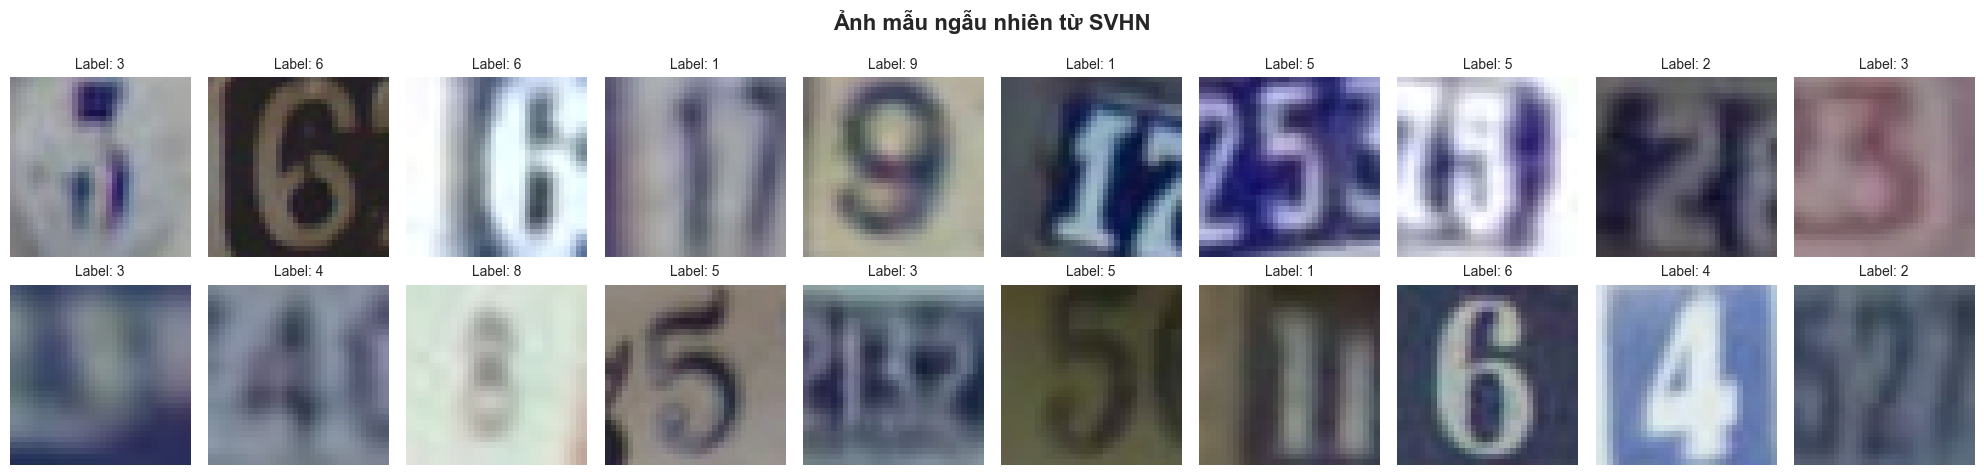

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Ảnh mẫu ngẫu nhiên từ SVHN', fontsize=16, fontweight='bold')

np.random.seed(42)
for i in range(20):
    ax = axes[i // 10, i % 10]
    idx = np.random.randint(0, len(train_dataset))
    img = train_dataset.data[idx].transpose(1, 2, 0)
    label = train_dataset.labels[idx]
    ax.imshow(img)
    ax.set_title(f'Label: {label}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('image_01_random_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sample Grid - Mỗi class 8 ảnh

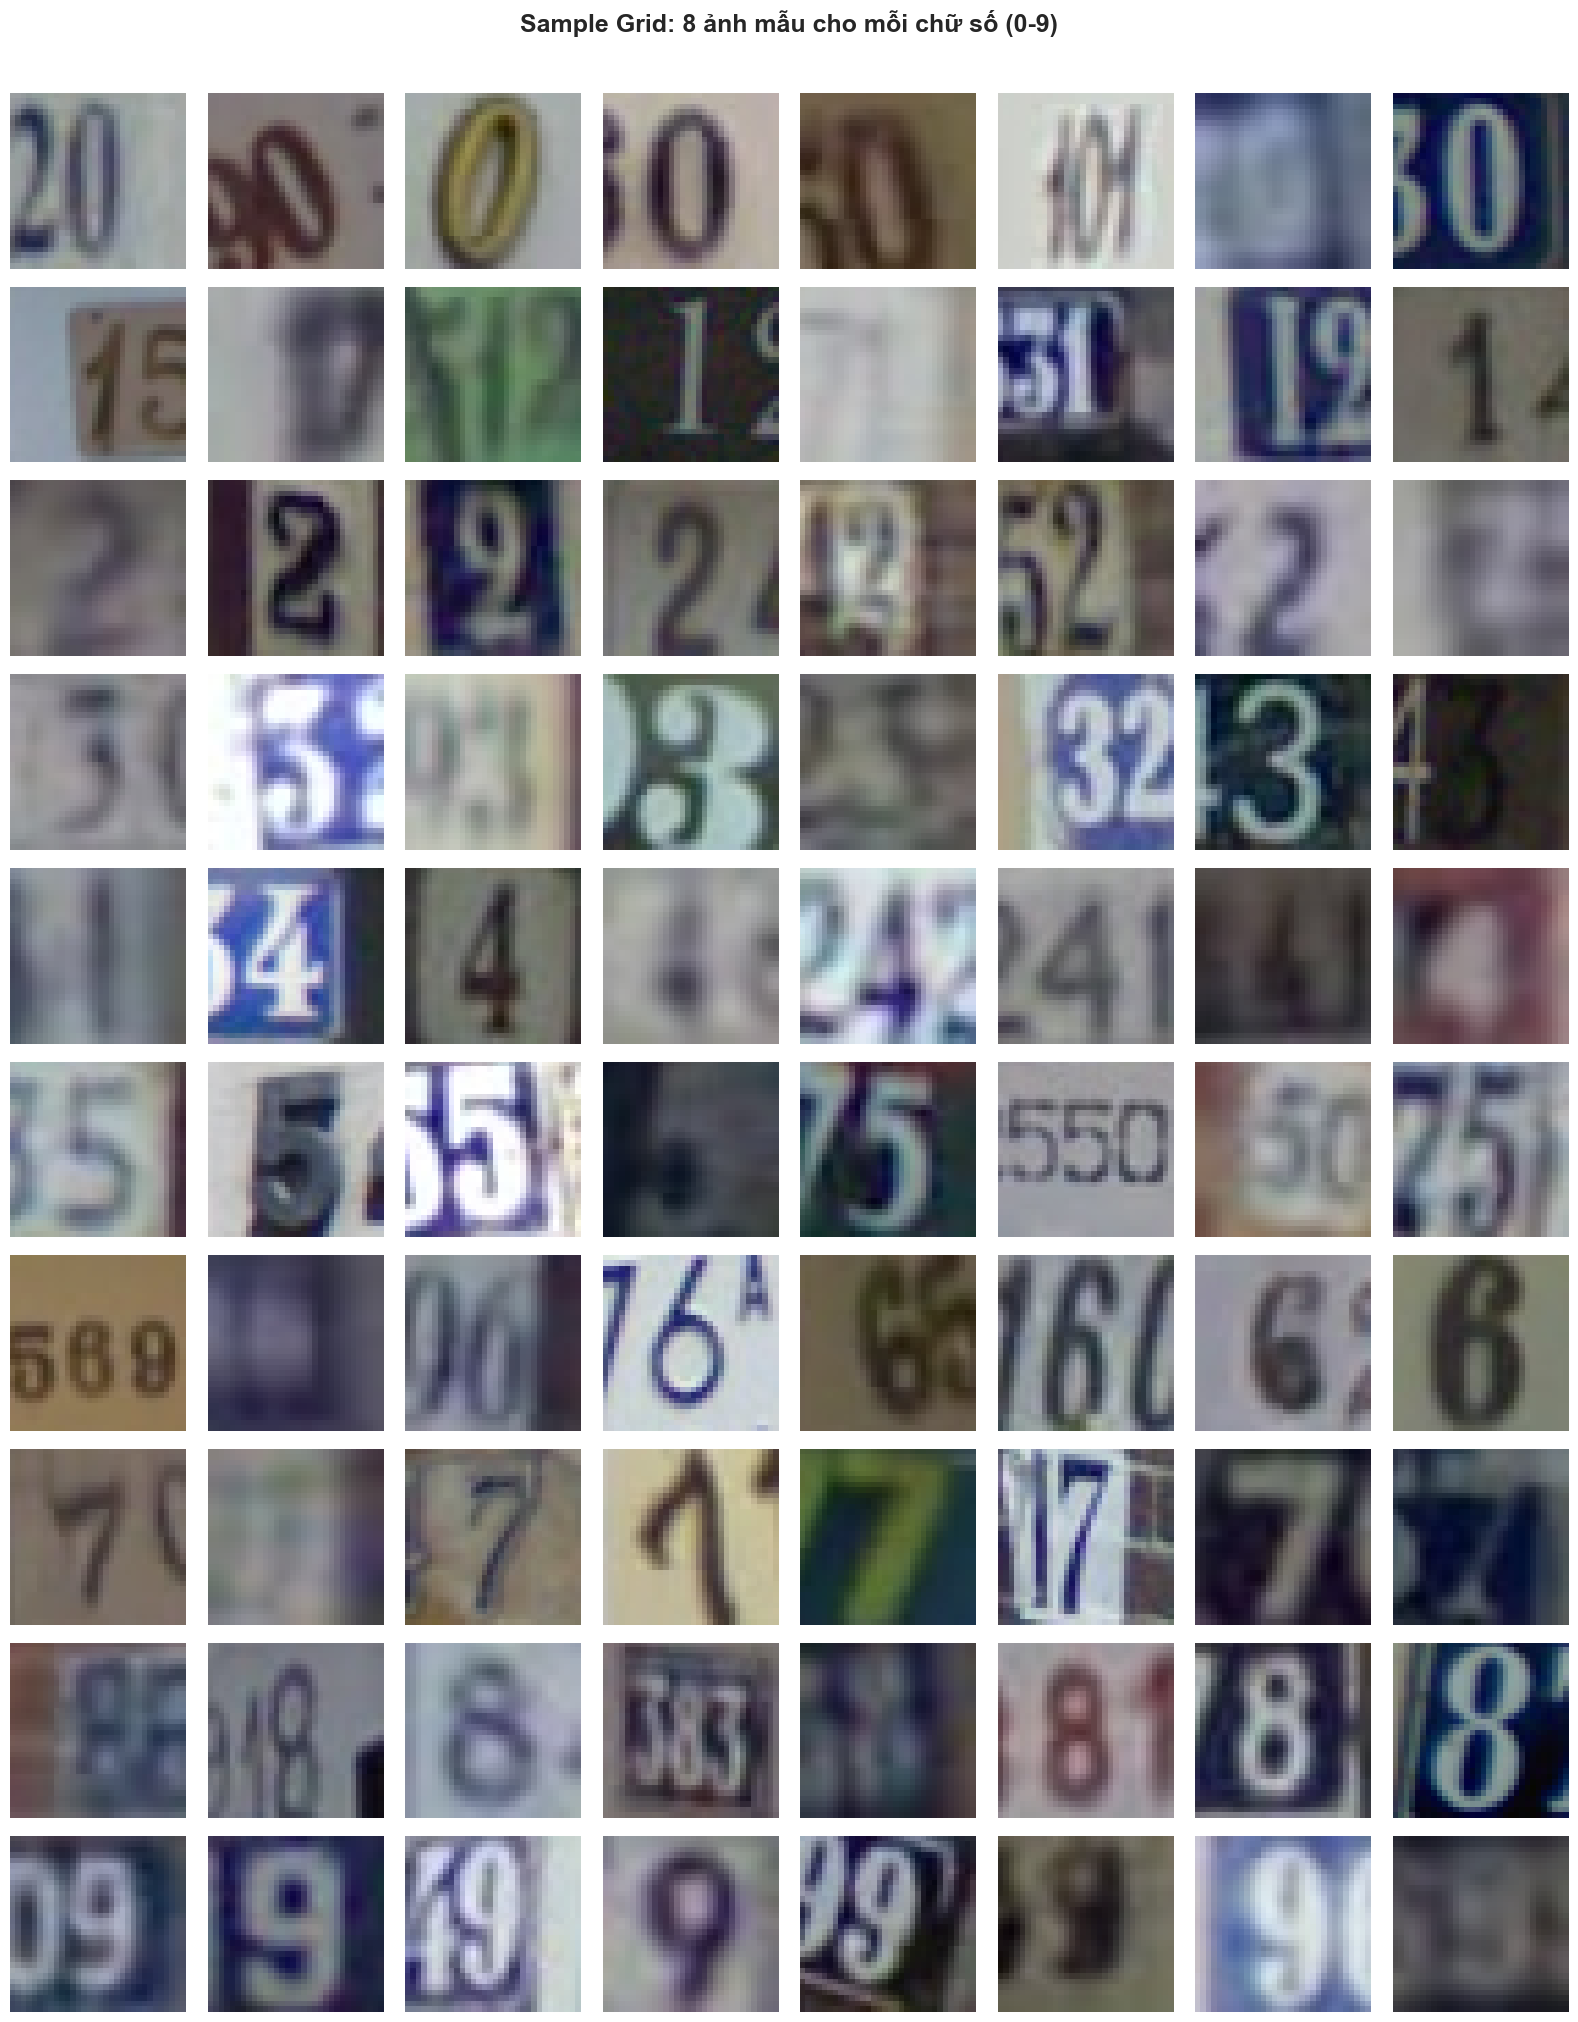

In [4]:
fig, axes = plt.subplots(10, 8, figsize=(16, 20))
fig.suptitle('Sample Grid: 8 ảnh mẫu cho mỗi chữ số (0-9)',
             fontsize=18, fontweight='bold', y=1.01)

np.random.seed(42)
for digit in range(10):
    indices = np.where(train_dataset.labels == digit)[0]
    selected = np.random.choice(indices, size=8, replace=False)
    for j, idx in enumerate(selected):
        ax = axes[digit, j]
        img = train_dataset.data[idx].transpose(1, 2, 0)
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(f'Digit {digit}', fontsize=13, fontweight='bold',
                         rotation=0, labelpad=40)

plt.tight_layout()
plt.savefig('image_02_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Phân phối nhãn (Label Distribution)

Training set:
  Digit 0:   4948 ảnh (6.8%)
  Digit 1:  13861 ảnh (18.9%)
  Digit 2:  10585 ảnh (14.4%)
  Digit 3:   8497 ảnh (11.6%)
  Digit 4:   7458 ảnh (10.2%)
  Digit 5:   6882 ảnh (9.4%)
  Digit 6:   5727 ảnh (7.8%)
  Digit 7:   5595 ảnh (7.6%)
  Digit 8:   5045 ảnh (6.9%)
  Digit 9:   4659 ảnh (6.4%)


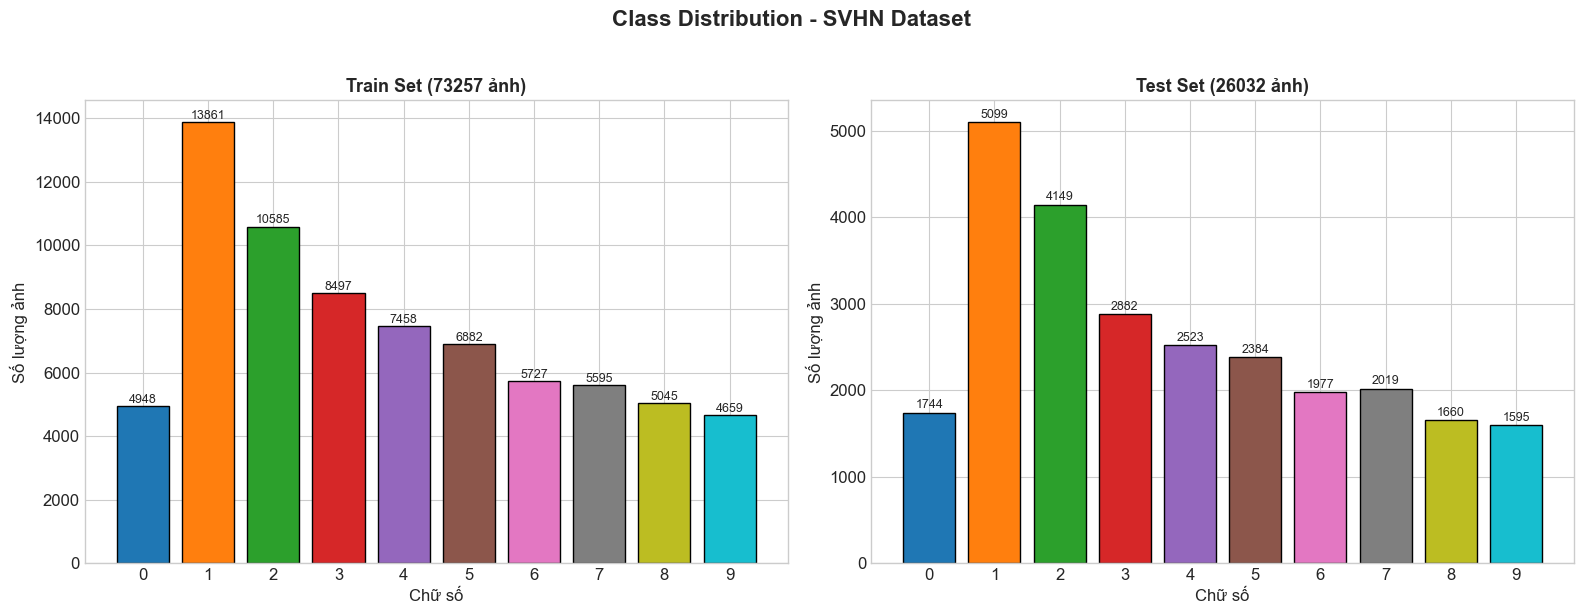


📌 Imbalance ratio: 2.98x


In [5]:
train_label_counts = Counter(train_dataset.labels)
train_label_counts = dict(sorted(train_label_counts.items()))
test_label_counts = Counter(test_dataset.labels)
test_label_counts = dict(sorted(test_label_counts.items()))

print('Training set:')
for label, count in train_label_counts.items():
    print(f'  Digit {label}: {count:>6} ảnh ({count/len(train_dataset)*100:.1f}%)')

digits = list(range(10))
train_counts = [train_label_counts[d] for d in digits]
test_counts = [test_label_counts[d] for d in digits]
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].bar(digits, train_counts, color=colors, edgecolor='black')
axes[0].set_title(f'Train Set ({len(train_dataset)} ảnh)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Chữ số')
axes[0].set_ylabel('Số lượng ảnh')
axes[0].set_xticks(digits)
for bar, val in zip(bars1, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, str(val), ha='center', fontsize=9)

bars2 = axes[1].bar(digits, test_counts, color=colors, edgecolor='black')
axes[1].set_title(f'Test Set ({len(test_dataset)} ảnh)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Chữ số')
axes[1].set_ylabel('Số lượng ảnh')
axes[1].set_xticks(digits)
for bar, val in zip(bars2, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(val), ha='center', fontsize=9)

plt.suptitle('Class Distribution - SVHN Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('image_03_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📌 Imbalance ratio: {max(train_counts)/min(train_counts):.2f}x')

## 6. Mean Image cho mỗi chữ số

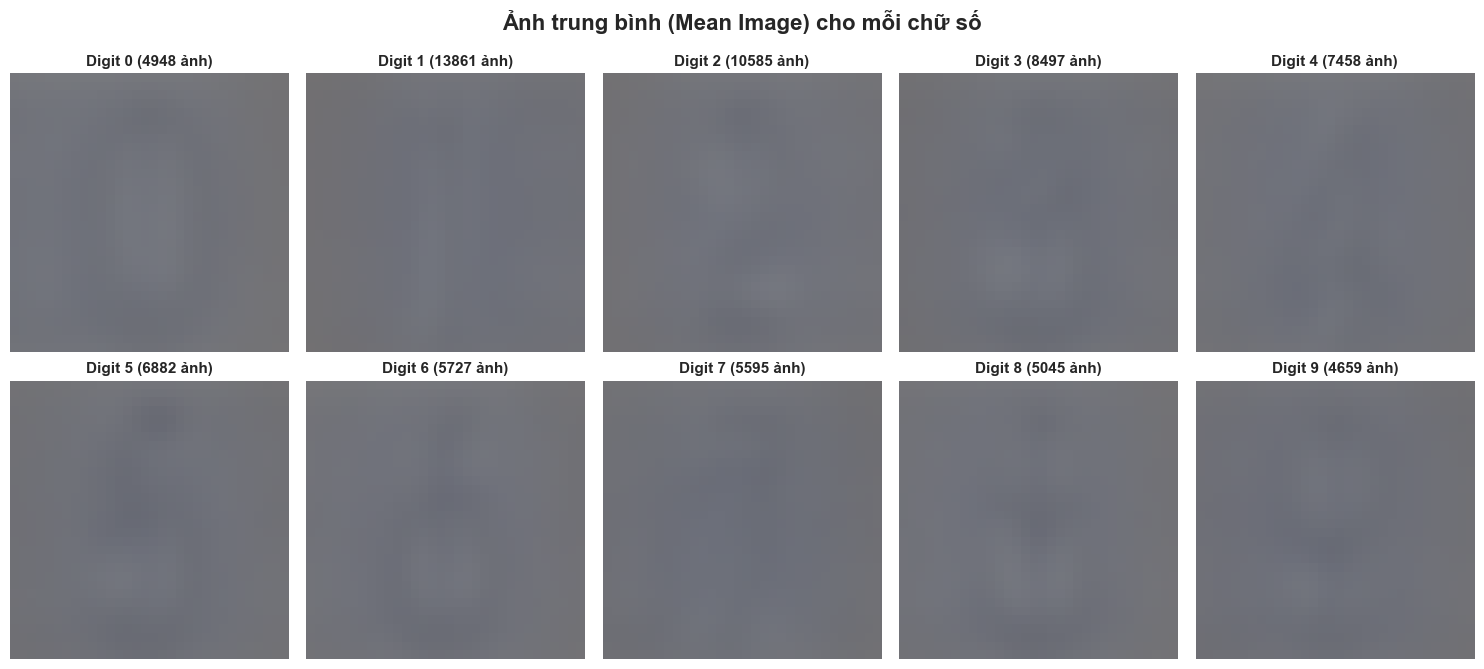

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Ảnh trung bình (Mean Image) cho mỗi chữ số', fontsize=16, fontweight='bold')

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    indices = np.where(train_dataset.labels == digit)[0]
    digit_images = train_dataset.data[indices].astype(np.float32)
    mean_img = digit_images.mean(axis=0).transpose(1, 2, 0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(f'Digit {digit} ({len(indices)} ảnh)', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('image_04_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Phân phối Pixel Intensity

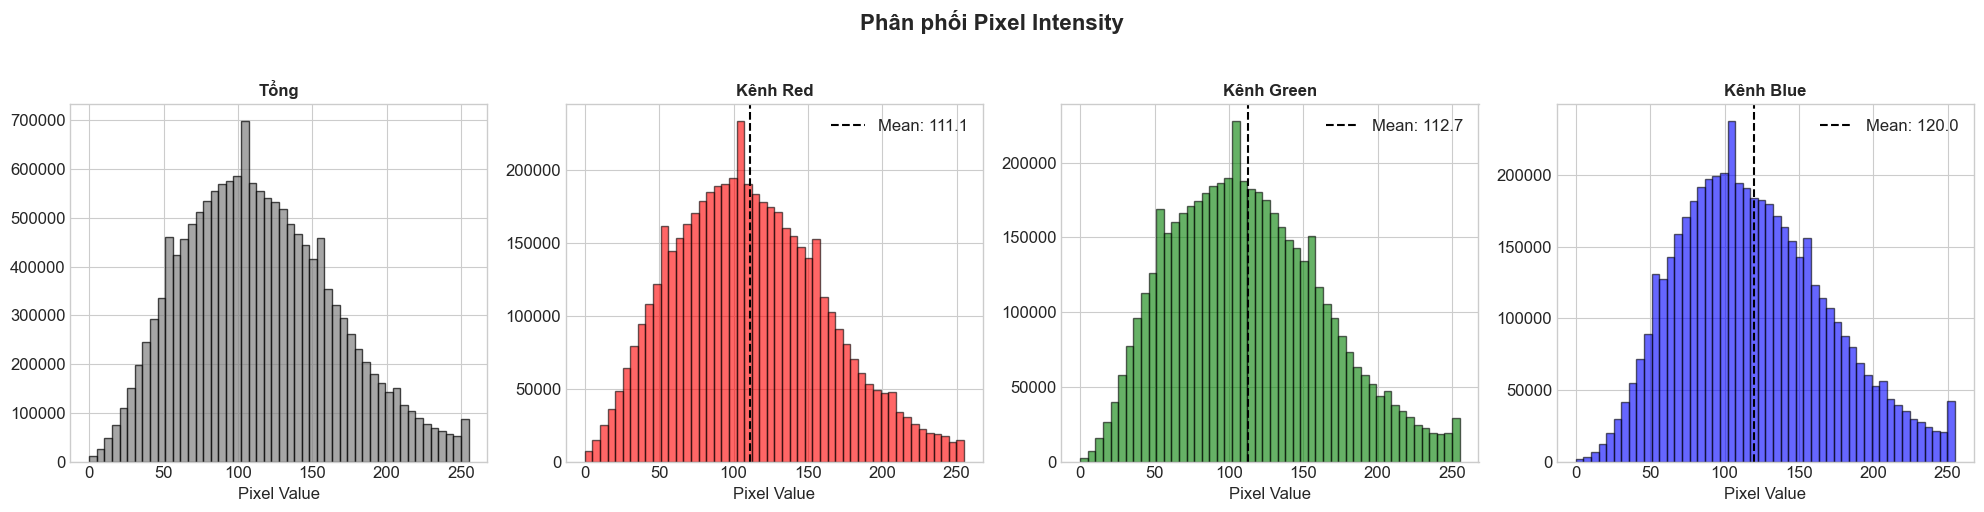

In [7]:
np.random.seed(42)
sample_indices = np.random.choice(len(train_dataset), 5000, replace=False)
sample_images = train_dataset.data[sample_indices]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].hist(sample_images.flatten(), bins=50, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_title('Tổng', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pixel Value')

for i, (name, color) in enumerate(zip(['Red', 'Green', 'Blue'], ['red', 'green', 'blue'])):
    ch = sample_images[:, i, :, :].flatten()
    axes[i+1].hist(ch, bins=50, color=color, edgecolor='black', alpha=0.6)
    axes[i+1].set_title(f'Kênh {name}', fontsize=12, fontweight='bold')
    axes[i+1].set_xlabel('Pixel Value')
    axes[i+1].axvline(ch.mean(), color='black', linestyle='--', label=f'Mean: {ch.mean():.1f}')
    axes[i+1].legend()

plt.suptitle('Phân phối Pixel Intensity', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('image_05_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Brightness theo class & Train vs Test

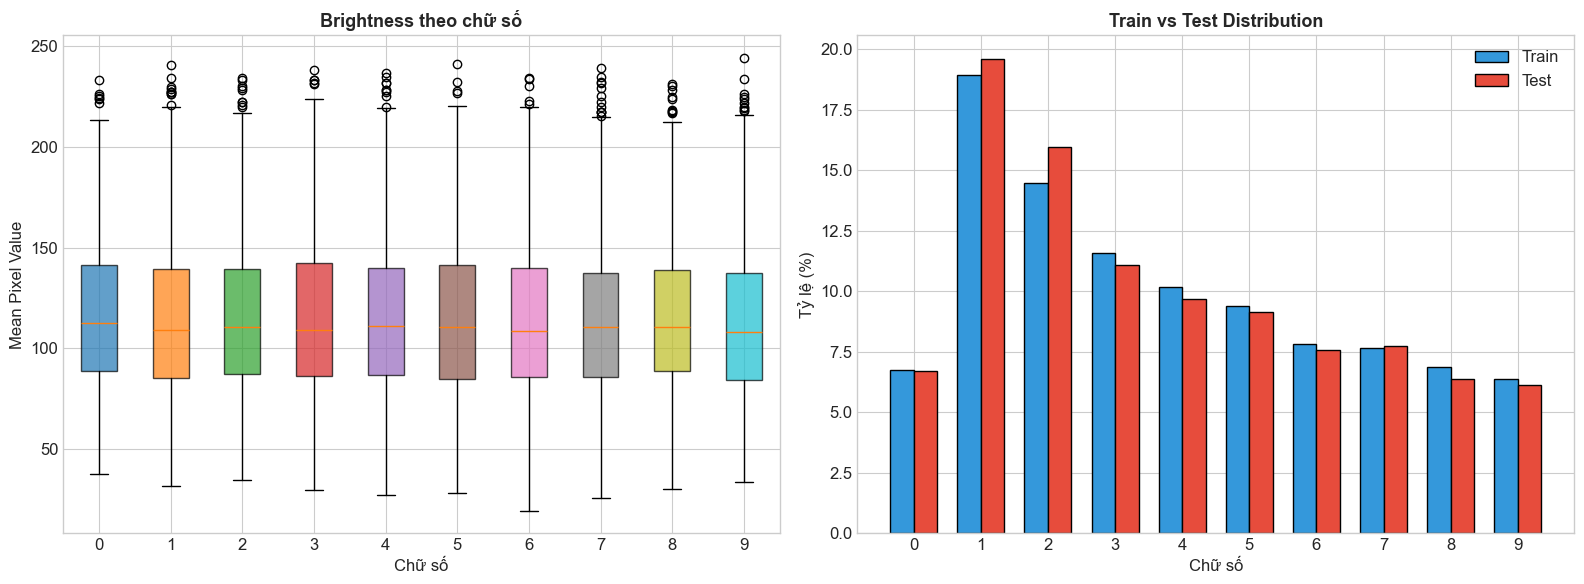

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Brightness by class
brightness_by_class = {}
np.random.seed(42)
for digit in range(10):
    indices = np.where(train_dataset.labels == digit)[0]
    sub = np.random.choice(indices, min(1000, len(indices)), replace=False)
    brightness_by_class[digit] = train_dataset.data[sub].mean(axis=(1, 2, 3))

bp = axes[0].boxplot([brightness_by_class[d] for d in range(10)],
                     labels=[str(d) for d in range(10)], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Brightness theo chữ số', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Chữ số')
axes[0].set_ylabel('Mean Pixel Value')

# Train vs Test
train_pct = np.array(train_counts) / sum(train_counts) * 100
test_pct = np.array(test_counts) / sum(test_counts) * 100
x = np.arange(10)
width = 0.35
axes[1].bar(x - width/2, train_pct, width, label='Train', color='#3498db', edgecolor='black')
axes[1].bar(x + width/2, test_pct, width, label='Test', color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Chữ số')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_title('Train vs Test Distribution', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].legend()

plt.tight_layout()
plt.savefig('image_06_brightness_and_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. RGB vs Grayscale & Ảnh khó nhận diện

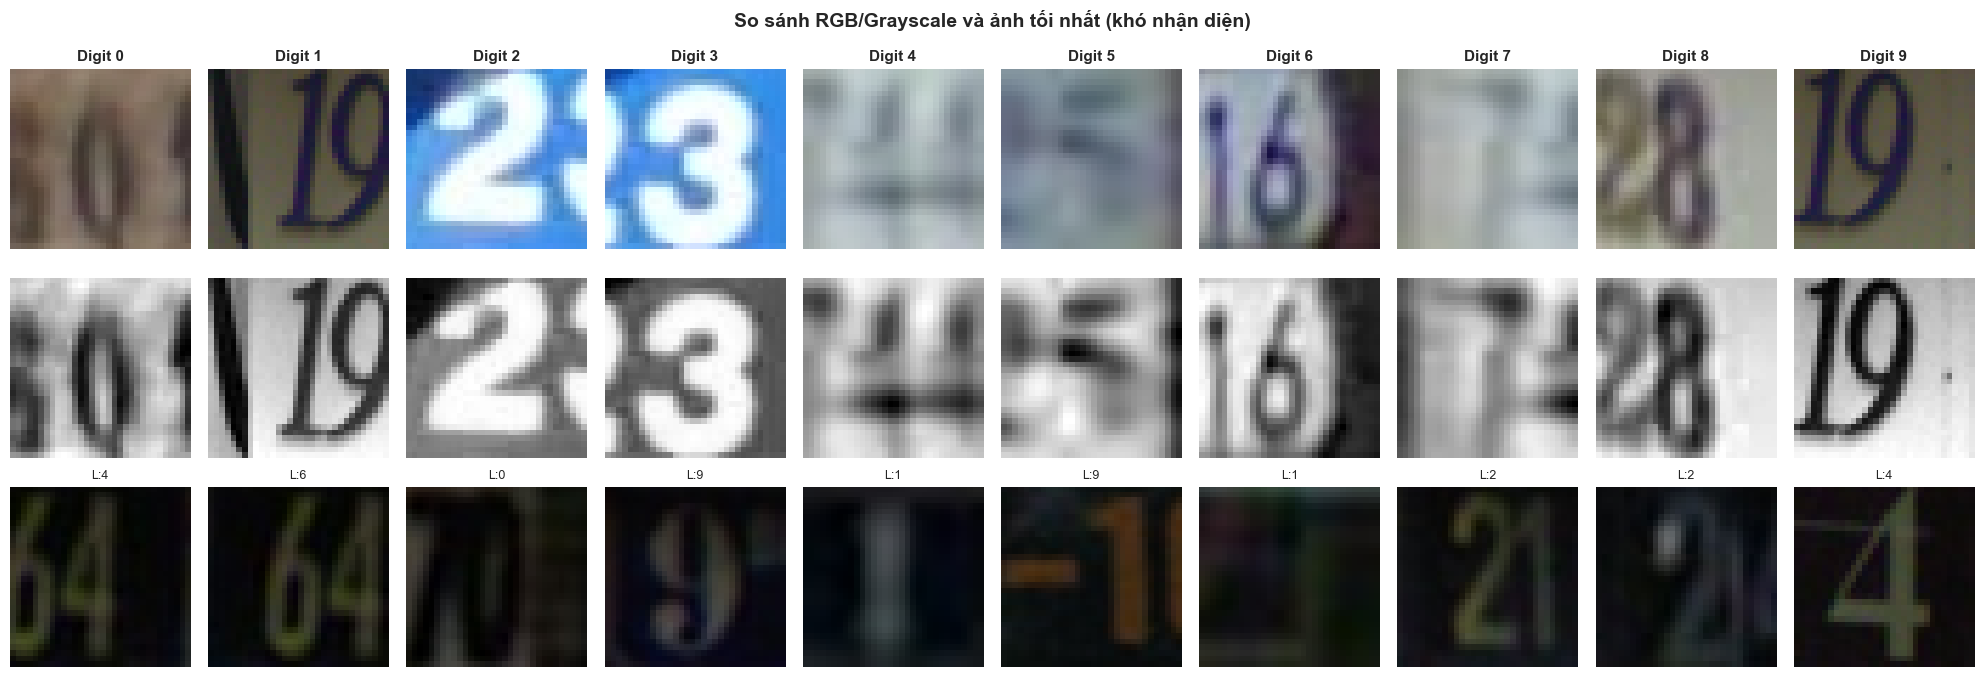

In [9]:
fig, axes = plt.subplots(3, 10, figsize=(20, 7))

# Row 1: RGB
for i in range(10):
    idx = np.where(train_dataset.labels == i)[0][0]
    img_rgb = train_dataset.data[idx].transpose(1, 2, 0)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f'Digit {i}', fontsize=11, fontweight='bold')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('RGB', fontsize=12, fontweight='bold', rotation=0, labelpad=35)

# Row 2: Grayscale
for i in range(10):
    idx = np.where(train_dataset.labels == i)[0][0]
    img_rgb = train_dataset.data[idx].transpose(1, 2, 0)
    img_gray = np.dot(img_rgb[..., :3], [0.2989, 0.5870, 0.1140])
    axes[1, i].imshow(img_gray, cmap='gray')
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Gray', fontsize=12, fontweight='bold', rotation=0, labelpad=35)

# Row 3: Darkest images
all_brightness = train_dataset.data.mean(axis=(1, 2, 3))
darkest = np.argsort(all_brightness)[:10]
for i, idx in enumerate(darkest):
    img = train_dataset.data[idx].transpose(1, 2, 0)
    axes[2, i].imshow(img)
    axes[2, i].set_title(f'L:{train_dataset.labels[idx]}', fontsize=9)
    axes[2, i].axis('off')
axes[2, 0].set_ylabel('Dark', fontsize=12, fontweight='bold', rotation=0, labelpad=35)

plt.suptitle('So sánh RGB/Grayscale và ảnh tối nhất (khó nhận diện)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('image_07_rgb_gray_dark.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Tổng kết Findings

**1. TỔNG QUAN:** 73,257 ảnh train + 26,032 ảnh test, 10 classes (0-9), 32x32 RGB.

**2. CLASS DISTRIBUTION:** Dataset bị class imbalance — chữ số 1 nhiều nhất, chữ số 0 ít nhất.

**3. CHẤT LƯỢNG ẢNH:** Kích thước đồng nhất 32x32. Brightness phân bố rộng, nhiều ảnh tối/noise do chụp ngoài trời.

**4. VẤN ĐỀ CHO MODELING:** Cần xử lý class imbalance, normalize pixels, có thể augment data.